In [ ]:
import pandas as pd
from scipy.stats import levene, shapiro
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# --- 1. Veri Yükleme ---
df = pd.read_csv('/content/sandwich.csv')
print(df.head())
print("\n")

   antCount        bread           topping butter
0        34          Rye  Ham and gherkins     no
1        47  Multi Grain     Peanut butter    yes
2        67        White  Ham and gherkins    yes
3        63  Multi Grain  Ham and gherkins    yes
4        65          Rye  Ham and gherkins     no




In [ ]:
# --- 2. Kategorik Değişkenleri Tanımlama ---
df['bread'] = df['bread'].astype('category')
df['topping'] = df['topping'].astype('category')
df['butter'] = df['butter'].astype('category')
print(df.dtypes)
print("\n")

antCount       int64
bread       category
topping     category
butter      category
dtype: object




In [ ]:
# --- 3. Tanımlayıcı İstatistikler ---
print("----- 3. Bread Türüne Göre Ant Sayısı -----")
print(df.groupby('bread')['antCount'].agg(['mean', 'std', 'count']))
print("\n")

print("----- 3. Topping Türüne Göre Ant Sayısı -----")
print(df.groupby('topping')['antCount'].agg(['mean', 'std', 'count']))
print("\n")

print("----- 3. Butter Durumuna Göre Ant Sayısı -----")
print(df.groupby('butter')['antCount'].agg(['mean', 'std', 'count']))
print("\n")

----- 3. Bread Türüne Göre Ant Sayısı -----
              mean        std  count
bread                               
Multi Grain  43.00  18.230843     12
Rye          44.25  13.396913     12
White        42.25  15.863767     12
Whole Grain  44.50  14.606972     12


----- 3. Topping Türüne Göre Ant Sayısı -----
                    mean        std  count
topping                                   
Ham and gherkins  55.500  12.055428     16
Peanut butter     40.375  14.183911     16
Yeast spread      34.625  11.158704     16


----- 3. Butter Durumuna Göre Ant Sayısı -----
          mean        std  count
butter                          
no      38.125  14.072213     24
yes     48.875  14.513300     24




<ipython-input-32-168088429>:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('bread')['antCount'].agg(['mean', 'std', 'count']))
<ipython-input-32-168088429>:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('topping')['antCount'].agg(['mean', 'std', 'count']))
<ipython-input-32-168088429>:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('butter')['antCount'].agg(['mean

In [ ]:
# --- 4. ANOVA Modeli Kurulumu ---
model = ols('antCount ~ C(bread) * C(topping) * C(butter)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                                sum_sq    df          F    PR(>F)
C(bread)                         40.50   3.0   0.142043  0.933761
C(topping)                     3720.50   2.0  19.572994  0.000009
C(butter)                      1386.75   1.0  14.590969  0.000830
C(bread):C(topping)             577.00   6.0   1.011837  0.440987
C(bread):C(butter)              378.75   3.0   1.328365  0.288413
C(topping):C(butter)             56.00   2.0   0.294608  0.747479
C(bread):C(topping):C(butter)  2345.50   6.0   4.113108  0.005597
Residual                       2281.00  24.0        NaN       NaN


In [ ]:
# --- 5. Artıkların Normal Dağılım Testi (Shapiro-Wilk) ---
print("----- 5. Artıkların Normal Dağılım Testi (Shapiro-Wilk) -----")
w, p = shapiro(model.resid)
print(f"Shapiro-Wilk test sonucu: W={w:.4f}, p-değeri={p:.4f}")
print("\n")

----- 5. Artıkların Normal Dağılım Testi (Shapiro-Wilk) -----
Shapiro-Wilk test sonucu: W=0.9896, p-değeri=0.9430




In [ ]:
# --- 6. Varyans Homojenliği Testi (Levene) ---
print("----- 6. Varyans Homojenliği Testi (Levene) -----")
for factor in ['bread', 'topping', 'butter']:
    groups = [group['antCount'].values for name, group in df.groupby(factor)]
    stat, p_val = levene(*groups)
    print(f"{factor.capitalize()} için Levene testi: Stat={stat:.4f}, p-değeri={p_val:.4f}")
print("\n")

----- 6. Varyans Homojenliği Testi (Levene) -----
Bread için Levene testi: Stat=0.5266, p-değeri=0.6663
Topping için Levene testi: Stat=0.6345, p-değeri=0.5349
Butter için Levene testi: Stat=0.0014, p-değeri=0.9702




<ipython-input-35-2773429514>:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group['antCount'].values for name, group in df.groupby(factor)]


In [ ]:
# --- 7. ANOVA Tablosu ---
print("----- 7. ANOVA Tablosu (Tip 2) -----")
anova_table = anova_lm(model, typ=2)
print(anova_table)
print("\n")

----- 7. ANOVA Tablosu (Tip 2) -----
                                sum_sq    df          F    PR(>F)
C(bread)                         40.50   3.0   0.142043  0.933761
C(topping)                     3720.50   2.0  19.572994  0.000009
C(butter)                      1386.75   1.0  14.590969  0.000830
C(bread):C(topping)             577.00   6.0   1.011837  0.440987
C(bread):C(butter)              378.75   3.0   1.328365  0.288413
C(topping):C(butter)             56.00   2.0   0.294608  0.747479
C(bread):C(topping):C(butter)  2345.50   6.0   4.113108  0.005597
Residual                       2281.00  24.0        NaN       NaN




In [ ]:
# --- 8. Tukey HSD Testleri ---
print("----- 8. Tukey HSD Testleri -----")
for factor in ['bread', 'topping', 'butter']:
    print(f"Tukey HSD Testi: {factor.capitalize()}")
    tukey_result = pairwise_tukeyhsd(endog=df['antCount'], groups=df[factor], alpha=0.05)
    print(tukey_result)
    print("\n")


----- 8. Tukey HSD Testleri -----
Tukey HSD Testi: Bread
      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
   group1      group2   meandiff p-adj   lower    upper  reject
---------------------------------------------------------------
Multi Grain         Rye     1.25 0.9973 -15.7843 18.2843  False
Multi Grain       White    -0.75 0.9994 -17.7843 16.2843  False
Multi Grain Whole Grain      1.5 0.9954 -15.5343 18.5343  False
        Rye       White     -2.0 0.9892 -19.0343 15.0343  False
        Rye Whole Grain     0.25    1.0 -16.7843 17.2843  False
      White Whole Grain     2.25 0.9848 -14.7843 19.2843  False
---------------------------------------------------------------


Tukey HSD Testi: Topping
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
     group1          group2    meandiff p-adj   lower   upper  reject
---------------------------------------------------------------------
Ham and gherkins Peanut butter  -15.125 0.0038 -25.862  -4.388   T

----- 9. Kutu Grafikler Çiziliyor -----


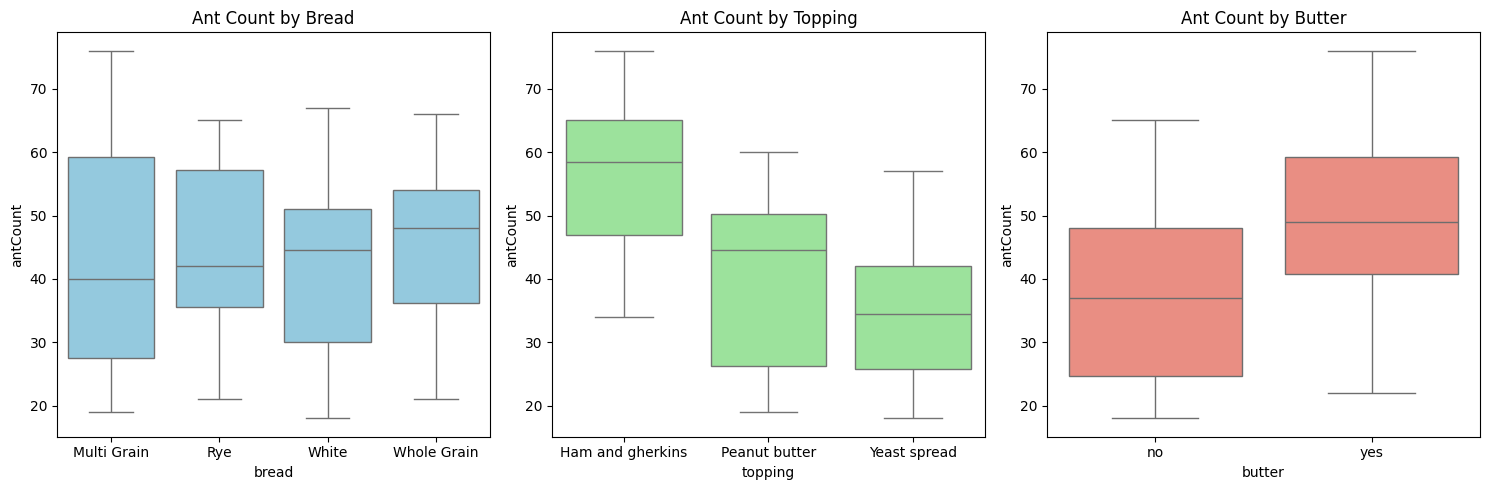

In [ ]:
print("----- 9. Kutu Grafikler Çiziliyor -----")
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x='bread', y='antCount', data=df, color='skyblue')
plt.title('Ant Count by Bread')

plt.subplot(1, 3, 2)
sns.boxplot(x='topping', y='antCount', data=df, color='lightgreen')
plt.title('Ant Count by Topping')

plt.subplot(1, 3, 3)
sns.boxplot(x='butter', y='antCount', data=df, color='salmon')
plt.title('Ant Count by Butter')

plt.tight_layout()
plt.show()

----- 10. Artıkların QQ Grafiği -----


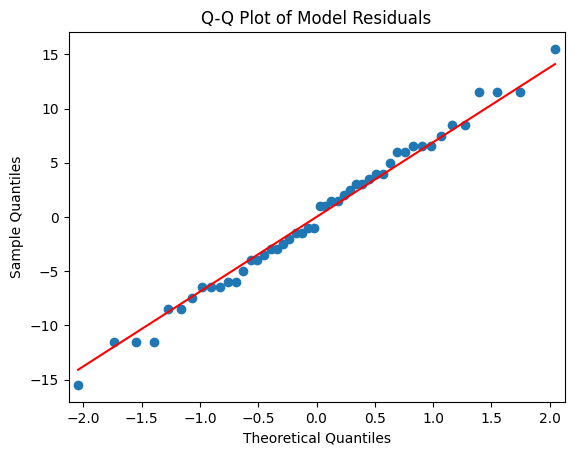

In [ ]:
# --- 10. Artıkların QQ Grafiği ---
print("----- 10. Artıkların QQ Grafiği -----")
sm.qqplot(model.resid, line='s')
plt.title('Q-Q Plot of Model Residuals')
plt.show()

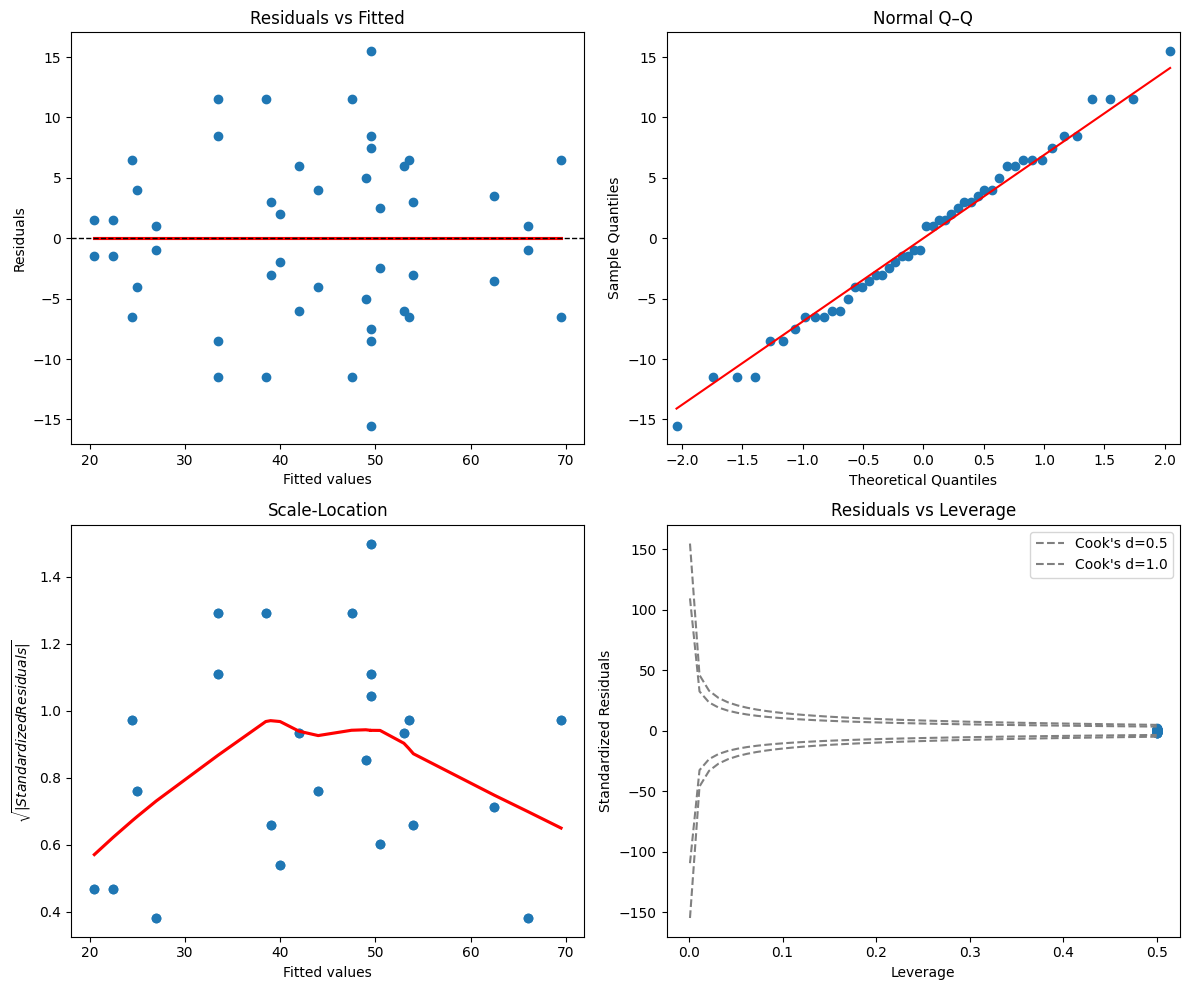

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import seaborn as sns

# Model residuals and fitted values
residuals = model.resid
fitted = model.fittedvalues
influence = model.get_influence()
standardized_residuals = influence.resid_studentized_internal
leverage = influence.hat_matrix_diag
cooks = influence.cooks_distance[0]

# Square root of standardized residuals for Scale-Location plot
sqrt_std_resid = np.sqrt(np.abs(standardized_residuals))

# Start plotting
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Top-left: Residuals vs Fitted ---
axes[0, 0].scatter(fitted, residuals)
sns.regplot(x=fitted, y=residuals, lowess=True, ax=axes[0, 0], scatter=False, color='red')
axes[0, 0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0, 0].set_title("Residuals vs Fitted")
axes[0, 0].set_xlabel("Fitted values")
axes[0, 0].set_ylabel("Residuals")

# --- Top-right: Q-Q plot ---
sm.qqplot(residuals, line='s', ax=axes[0, 1])
axes[0, 1].set_title("Normal Q–Q")

# --- Bottom-left: Scale-Location ---
axes[1, 0].scatter(fitted, sqrt_std_resid)
sns.regplot(x=fitted, y=sqrt_std_resid, lowess=True, ax=axes[1, 0], scatter=False, color='red')
axes[1, 0].set_title("Scale-Location")
axes[1, 0].set_xlabel("Fitted values")
axes[1, 0].set_ylabel(r'$\sqrt{|Standardized Residuals|}$')

# --- Bottom-right: Residuals vs Leverage ---
axes[1, 1].scatter(leverage, standardized_residuals)
sns.regplot(x=leverage, y=standardized_residuals, lowess=True, ax=axes[1, 1], scatter=False, color='red')
axes[1, 1].set_title("Residuals vs Leverage")
axes[1, 1].set_xlabel("Leverage")
axes[1, 1].set_ylabel("Standardized Residuals")

# Cook's distance contours
from matplotlib import pyplot
def add_cooks_distance_contours(ax, leverage, cooks, model):
    p = model.df_model + 1  # number of parameters
    n = model.nobs
    # Add 0.5 and 1.0 Cook's distance lines
    for d in [0.5, 1.0]:
        x = np.linspace(0.001, max(leverage), 50)
        y = np.sqrt(d * p * (1 - x) / x)
        ax.plot(x, y, label=f"Cook's d={d}", ls='--', color='grey')
        ax.plot(x, -y, ls='--', color='grey')
    ax.legend()

add_cooks_distance_contours(axes[1, 1], leverage, cooks, model)

plt.tight_layout()
plt.show()
